<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_57_tensorflow_2_0_rev10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensorflow 2.0
- Eager execution mode: skip all the Graph and Session (now, becomes much like a simple Python code (numpy code).
- Tensors 1.0
  - Graph: relate the nodes you created
  - Session:class for performing computation on a graph

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD

In [2]:
tf.__version__

'2.20.0'

## Tensors
- A tf.Tensor is an object that represents a multidimensional array of elements.
- A tf.Tensor has the following properties:
  - a single data type (float32, int32, or string, for example)
  - a shape
- two primary types:
  - constant: Tensor (값이 불변, 연산에 사용되면 새로운 Tensor 생성, e.g. y=x+1)
  - Variable: Tensor 의 특별한 형태로 값의 변경이 가능한 객체 (주로 parameter)

- Tensor (tf.constant, 연산 결과 등)
  - 불변(immutable): 한 번 생성되면 내부 값을 직접 수정할 수 없음.
  - 연산을 하면 새로운 텐서가 만들어질 뿐, 기존 텐서가 바뀌지 않음.
  - 예: x = tf.constant([1,2,3]); y = x + 1 → y는 새로운 텐서, x는 그대로.
- Variable (tf.Variable)
  - 가변(mutable): 학습 과정에서 값이 계속 업데이트되어야 하므로 변경 가능.
  - assign() 메서드를 통해 값을 갱신할 수 있음.

- TensorFlow에서 대부분의 연산은 새로운 Tensor를 생성한다. 반면에 Variable은 오직 tf.Variable()을 통해서만 만들어지고, 그 이후에는 assign() 같은 메서드로 값을 갱신할 수 있다.

In [3]:
# Compute some values using a Tensor
c = tf.constant([[1.0, 2.0],
                 [3.0, 4.0]])
d = tf.constant([[1.0, 1.0],
                 [0.0, 1.0]])
e = tf.matmul(c, d)
print(e, c@d)     # matrix multiplication


tf.Tensor(
[[1. 3.]
 [3. 7.]], shape=(2, 2), dtype=float32) tf.Tensor(
[[1. 3.]
 [3. 7.]], shape=(2, 2), dtype=float32)


In [4]:
type(e)    # eager tensor gives you access to a useful function, numpy

tensorflow.python.framework.ops.EagerTensor

- EagerTensor: Tensor is a EagerTensor by default in tf 2.x (objects, and operations are evaluated immediately.)

In [5]:
e

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 3.],
       [3., 7.]], dtype=float32)>

In [6]:
e.numpy()

array([[1., 3.],
       [3., 7.]], dtype=float32)

In [7]:
# constructing a tensor from a numpy array or pandas dataframe

a = np.array([1, 2, 3])
b = tf.constant(a)  # tf.Tensor (immutable)
c = tf.Variable(a)  # tf.Variable (mutable)
a, b, c

(array([1, 2, 3]),
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 2, 3])>,
 <tf.Variable 'Variable:0' shape=(3,) dtype=int64, numpy=array([1, 2, 3])>)

In [10]:
a[0] = 4  # TensorFlow가 tf.constant()나 tf.Variable()을 생성할 때 기본적으로 기존 NumPy 배열의 값을
          # 복사(Copy)하여 새로운 메모리 공간에 텐서를 만든다.
a, b, c

(array([4, 2, 3]),
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 2, 3])>,
 <tf.Variable 'Variable:0' shape=(3,) dtype=int64, numpy=array([1, 2, 3])>)

In [12]:
try:
    c[1] = 7
except:
    print ("Error: tf.Variable의 값을 바꿀 때는 반드시 .assign() 계열의 텐서플로 전용 메서드 시용해야 한다.")

Error: tf.Variable의 값을 바꿀 때는 반드시 .assign() 계열의 텐서플로 전용 메서드 시용해야 한다.


In [13]:
c[1].assign(7); c

<tf.Variable 'Variable:0' shape=(3,) dtype=int64, numpy=array([1, 7, 3])>

In [14]:
b, c

(<tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 2, 3])>,
 <tf.Variable 'Variable:0' shape=(3,) dtype=int64, numpy=array([1, 7, 3])>)

In [15]:
try:
    b[1].assign(9)
except:
    print ("Error: immutable.")

Error: immutable.


- direct assignment (=) is allowd on tf.Variable, but it create a new object (not allowd to update the tensor by direct assignment)

In [16]:
W = tf.Variable(1.0)
print(id(W))
W = W - 0.1 * W  # allowed, but it creates a new tensor, it doesn't directly modify W
W, id(W)

134253979037776


(<tf.Tensor: shape=(), dtype=float32, numpy=0.8999999761581421>,
 134253978557072)

In [17]:
W = tf.Variable(1.0)
# W -= 0.1*W       # not allowed to directly change the content by '='
W.assign_sub(0.1*W) # Use assign_sub for in-place modification

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=0.8999999761581421>

In [18]:
W = tf.Variable(1.0)
print(id(W))
W.assign_sub(0.1*W)   # in-place operation (recommended): w = w - 0.1*w
W, id(W)

134253979037488


(<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.8999999761581421>,
 134253979037488)

- tensorflow tensors and numpy array
  - numpy uses 64-bits (int64 and float64)
  - tf uses 32-bits (tf.int32 and tf.float32)

In [19]:
n1 = np.array([[1.,2.], [3.,4.]])
n2 = np.array([[1,2],[3,4]])
n1.dtype, n2.dtype     # numpy uses 64 bit in default

(dtype('float64'), dtype('int64'))

In [20]:
t1 = tf.constant([[1.,2.],[3.,4.]])
t2 = tf.constant([[1,2],[3,4]])
t1.dtype, t2.dtype     # tensor uses 32 bit

(tf.float32, tf.int32)

In [21]:
n1-1, n2-1

(array([[0., 1.],
        [2., 3.]]),
 array([[0, 1],
        [2, 3]]))

In [22]:
t1-1, t2-1

(<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[0., 1.],
        [2., 3.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[0, 1],
        [2, 3]], dtype=int32)>)

In [23]:
n1 + t1    # automatically convert numpy float to a tf.float before addition

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 4.],
       [6., 8.]], dtype=float32)>

In [24]:
t1[0,1]

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

- tf.constant() is immutable
- tf.Variable() is mutable. Use assign() or assign_add() instead of direct assignment(=)

In [25]:
# tf.Variable is mutable.
t2 = tf.Variable(n1)
t2

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float64, numpy=
array([[1., 2.],
       [3., 4.]])>

In [26]:
try:
    t2[0,0] = 7
except:
    print("Error: 'ResourceVariable' object does not support item assignment")

Error: 'ResourceVariable' object does not support item assignment


In [27]:
# can be modified in place with assign(), assign_sub(), assign_add()
t2[0,0].assign(7)
t2

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float64, numpy=
array([[7., 2.],
       [3., 4.]])>

In [28]:
t2.assign(2 * t2)
t2

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float64, numpy=
array([[14.,  4.],
       [ 6.,  8.]])>

- operation between different data types

In [29]:
print(tf.constant(2.7) + 7)              # tensor (op) numbers -> automatic conversion
print(tf.constant(2.7) + 7.0)
print(tf.constant(2.7) + np.array(7.0))  # tensor (op) numpy -> automatic conversion
print(tf.constant(2.7) + np.array(7))

tf.Tensor(9.7, shape=(), dtype=float32)
tf.Tensor(9.7, shape=(), dtype=float32)
tf.Tensor(9.7, shape=(), dtype=float32)
tf.Tensor(9.7, shape=(), dtype=float32)


In [30]:
try:
    tf.constant(2.7) + tf.constant(5)    # tensors -> no automatic conversion !
except:
    print("error")

error


In [31]:
tf.constant(2.7) + tf.cast(tf.constant(5), dtype=tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=7.699999809265137>

- When working with both TensorFlow tensors and NumPy arrays, TensorFlow will attempt to handle data type conversions automatically.
- But, operations between two TensorFlow tensors, TensorFlow is more strict about ensuring that the data types match.
- to convert data type, use tf.cast().

In [32]:
n = np.array(7.)
print(tf.constant(n).dtype, tf.constant(2.7).dtype)
try:
    tf.constant(n) + tf.constant(2.7)      # causing data type mismatch error !
except:
    print("error")

<dtype: 'float64'> <dtype: 'float32'>
error


In [33]:
tf.cast(tf.constant(n), tf.float32) + tf.constant(2.7)

<tf.Tensor: shape=(), dtype=float32, numpy=9.699999809265137>

In [34]:
n1 = np.array([[1.,2.],
               [3.,4.]])
t3, t4  = tf.constant(n1), tf.constant([[2.3, 1.2], [2.1, 1.1]])
t3, t4

(<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
 array([[1., 2.],
        [3., 4.]])>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[2.3, 1.2],
        [2.1, 1.1]], dtype=float32)>)

In [35]:
try:
    t3 + t4
except:
    print("Error: double can not be added with float. use tf.cast()")

Error: double can not be added with float. use tf.cast()


In [36]:
#  print(t3 + t4)   # error
tf.cast(t3, tf.float32) + t4

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[3.3, 3.2],
       [5.1, 5.1]], dtype=float32)>

# Linear Regression with Numpy

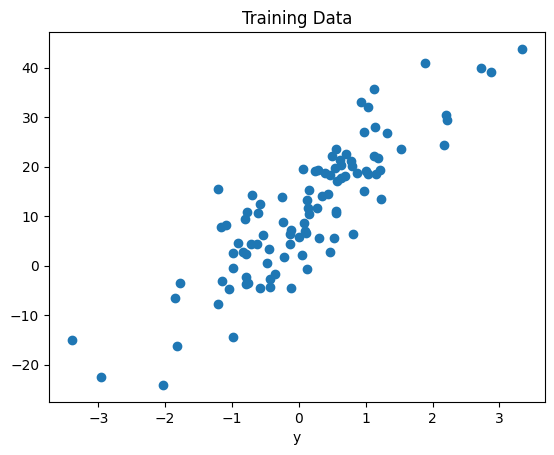

In [37]:
np.random.seed(17)
n = 100
x = np.random.randn(n)               # batch size
y = x*10 + 10                        # w=10, b=10
y = y + np.random.randn(n) * 7       # add noise

plt.scatter(x, y)
plt.xlabel('x')
plt.xlabel('y')
plt.title("Training Data")
plt.show()

epoch= 199 error= 44.039056119990974 w= 10.253254672242234 b= 9.903642788225548


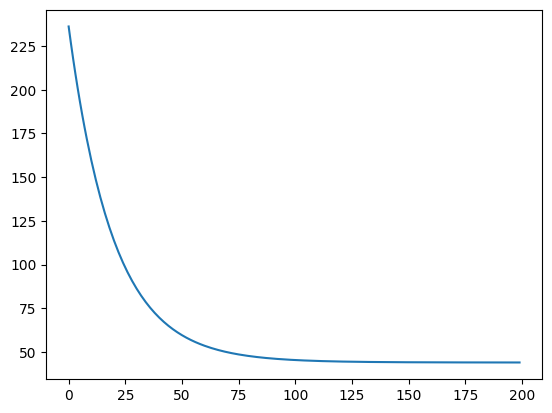

In [38]:
w, b = np.random.randn(), np.random.randn()

lr = 0.02
n_epoch = 200
lossHistory = []

for epoch in range(n_epoch):
    y_pred = w*x + b
    loss = ((y_pred - y)**2).mean()  # MSE

    w = w - lr* ((y_pred - y)*x).mean()
    b = b - lr* (y_pred - y).mean()
    lossHistory.append(loss)

print('epoch=', epoch, 'error=', loss, 'w=', w, 'b=', b)

plt.plot(lossHistory)

# Linear Regression using Tensorflow 2.0

### Version 1

()
    0|   -2.5451|    0.9159|378.381378
   10|    0.5214|     2.814|242.332443
   20|    2.8591|     4.309|161.778473
   30|    4.6404|     5.489|114.038094
   40|    5.9968|      6.42| 85.714661
   50|    7.0293|     7.157| 68.890579
   60|    7.8145|     7.741| 58.883469
   70|    8.4114|     8.203| 52.921947
   80|    8.8647|     8.571| 49.364365
   90|    9.2087|     8.863| 47.237202
  100|    9.4695|     9.095| 45.962578
  110|    9.6671|      9.28| 45.196949
  120|    9.8165|     9.428| 44.735825
  130|    9.9294|     9.546| 44.457291
  140|   10.0147|      9.64| 44.288502
  150|   10.0789|     9.716| 44.185860
  160|   10.1272|     9.776| 44.123203
  170|   10.1634|     9.825| 44.084805
  180|   10.1906|     9.864| 44.061172
  190|   10.2109|     9.896| 44.046555


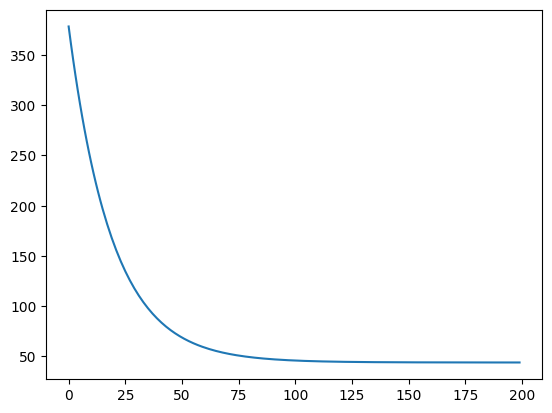

In [39]:
W = tf.Variable(-2.9)
b = tf.Variable(0.7)
print(W.shape)

learning_rate = 0.02
lossHistory = []

for i in range(200):
    y_pred = W * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))

    W_grad = tf.reduce_mean((y_pred - y) * x)  # 차원을 줄이는 동작
    b_grad = tf.reduce_mean(y_pred - y)

    # W = W - learning_rate * W_grad
    # b = b - learning_rate * b_grad

    W.assign_sub(learning_rate * W_grad)       # update
    b.assign_sub(learning_rate * b_grad)

    lossHistory.append(loss)
    if i % 10 == 0:
        print("{:5}|{:10.4f}|{:10.4}|{:10.6f}".format(i, W.numpy(), b.numpy(), loss))

plt.plot(lossHistory)

### Version 2 (using tf.GradientTape())
- tape에 기록한다는 말은, tf.GradientTape() 블록 안에서 일어난 연산 과정(operations)을 일종의 “녹화기”처럼 저장해 둔다는 뜻이다. 값 자체를 저장하는 게 아니라, 어떤 입력에 어떤 함수가 적용되었는지를 기록해 둔다. (미분은 symbolic 연산)
- tape.gradient(y, x)를 호출하면, 테이프는 이 기록을 거꾸로 따라가면서 연쇄 법칙(chain rule)을 적용.

    0|   -2.1902|     1.132|378.381378
   10|    3.1205|     4.474|160.143356
   20|    6.1804|     6.543| 84.576569
   30|    7.9393|     7.829| 58.286949
   40|    8.9474|     8.633| 49.084991
   50|    9.5233|     9.139| 45.839092
   60|    9.8509|     9.459| 44.682995
   70|   10.0364|     9.662| 44.266293
   80|   10.1407|     9.791| 44.113945
   90|   10.1989|     9.874| 44.057316
  100|   10.2310|     9.928| 44.035866
  110|   10.2486|     9.963| 44.027573
  120|   10.2580|     9.986| 44.024296
  130|   10.2630|      10.0| 44.022980
  140|   10.2655|     10.01| 44.022438
  150|   10.2667|     10.02| 44.022202
  160|   10.2672|     10.02| 44.022114
  170|   10.2674|     10.02| 44.022064
  180|   10.2674|     10.03| 44.022049
  190|   10.2674|     10.03| 44.022041


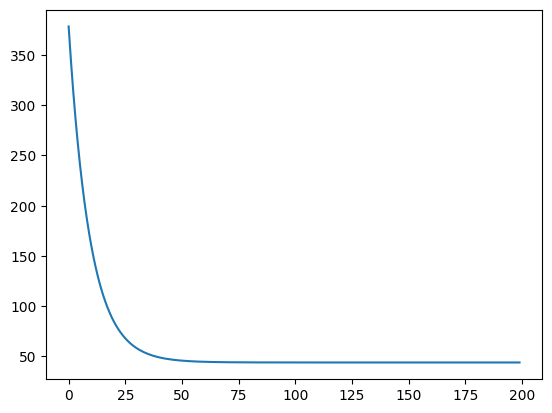

In [40]:
W = tf.Variable(-2.9)
b = tf.Variable(0.7)

learning_rate = 0.02
lossHistory = []

for i in range(200):
    with tf.GradientTape() as tape:   # 내부에 symbolic 미분 연산이 들어 있음
        y_pred = W * x + b
        loss = tf.reduce_mean(tf.square(y_pred - y))

    W_grad, b_grad = tape.gradient(loss, [W,b])  # dLoss/dw, dLoss/db

    W.assign_sub(learning_rate * W_grad)   # W is still a Variable.
    b.assign_sub(learning_rate * b_grad)
    #
    # W = W - learning_rate * W_grad
    # b = b - learning_rate * b_grad
    # will cause error (W will be changed from Variable -> Tensor)
    # then, tape.gradient will return None.

    lossHistory.append(loss)
    if i % 10 == 0:
        print("{:5}|{:10.4f}|{:10.4}|{:10.6f}".format(i, W.numpy(), b.numpy(), loss))

plt.plot(lossHistory)

In [ ]:
W_grad, W, cost

(<tf.Tensor: shape=(), dtype=float32, numpy=0.00030037760734558105>,
 <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=10.267328262329102>,
 <tf.Tensor: shape=(), dtype=float32, numpy=44.022037506103516>)

### Version 3 (tf.GradientTape() and opt.apply_gradients())
- opt.apply_gradients(): it allows you to explicitly compute gradients and apply them to variables, giving you more control over the process.
  - loss = ...
  - $opt = tf.optimizers.Adam()$
  - gradients = tape.gradient(loss, variables) \# Compute gradients with respect to variables
  - opt.apply_gradients(zip(gradients, variables))  \# Apply gradients to variables
  - 표준 방법
- opt.minimize(): it combines two steps: computing gradients and applying them to update the variables.
  - loss = ...
  - opt = tf.optimizers.Adam()

  - opt.minimize(loss, var_list=variables)  \# Compute gradients and update variables
  - not recommended.

    0|   -1.1256|      1.78|378.381378
   10|    7.6223|     7.566| 65.528748
   20|    9.6738|     9.265| 45.493729
   30|   10.1420|     9.783| 44.133778
   40|   10.2439|     9.947| 44.031811
   50|   10.2641|      10.0| 44.023022
   60|   10.2673|     10.02| 44.022144
   70|   10.2675|     10.03| 44.022045
   80|   10.2673|     10.03| 44.022038
   90|   10.2672|     10.03| 44.022038
  100|   10.2671|     10.03| 44.022030
  110|   10.2671|     10.03| 44.022030
  120|   10.2671|     10.03| 44.022030
  130|   10.2671|     10.03| 44.022030
  140|   10.2671|     10.03| 44.022038
  150|   10.2671|     10.03| 44.022038
  160|   10.2671|     10.03| 44.022038
  170|   10.2671|     10.03| 44.022038
  180|   10.2671|     10.03| 44.022038
  190|   10.2671|     10.03| 44.022038


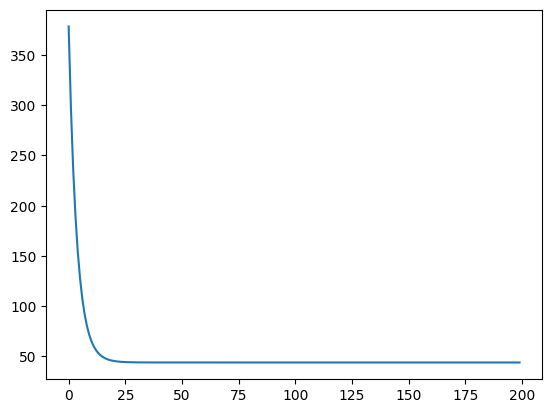

In [41]:
# customize the training loop

W = tf.Variable(-2.9)
b = tf.Variable(0.7)

learning_rate = 0.05
lossHistory = []

for i in range(200):
    with tf.GradientTape() as tape:
        y_pred = W * x + b
        cost = tf.reduce_mean(tf.square(y_pred - y))

    grads = tape.gradient(cost, [W, b])

    optimizer = tf.optimizers.SGD( learning_rate )
    optimizer.apply_gradients(zip(grads, [W,b]))   # w = w - eta*...

    lossHistory.append(cost)
    if i % 10 == 0:
        print("{:5}|{:10.4f}|{:10.4}|{:10.6f}".format(i, W.numpy(), b.numpy(), cost))

plt.plot(lossHistory)

# Multi-variables Regression

### Version 1

    0|    0.5750|    0.5933|    0.9045|327.358063
   50|    7.8232|    6.6958|     6.882| 35.078014
  100|    9.5265|    9.0240|     8.794|  7.615945
  150|    9.8934|    9.9308|     9.427|  4.554090


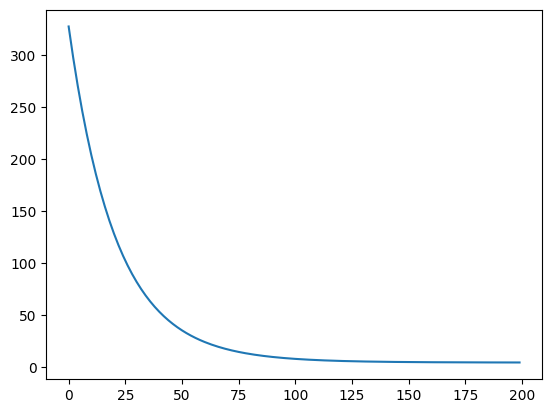

In [42]:
# two features (x1, x2)
np.random.seed(17)
n = 100
x1 = np.random.randn(n)
x2 = np.random.randn(n)
y = x1*10 + x2*10 + 10
y = y + np.random.randn(n) * 2

w1, w2, b = tf.Variable(0.3), tf.Variable(0.4), tf.Variable(0.7)
learning_rate = 0.01
lossHistory = []

for i in range(200):
    with tf.GradientTape() as tape:
        y_pred = x1 * w1 + x2 * w2 + b
        loss = tf.reduce_mean(tf.square(y_pred - y))

    grads = tape.gradient(loss, [w1, w2, b])

    optimizer = tf.optimizers.SGD( learning_rate )
    optimizer.apply_gradients(zip(grads, [w1, w2, b]))

    lossHistory.append(loss)
    if i % 50 == 0:
        print("{:5}|{:10.4f}|{:10.4f}|{:10.4}|{:10.6f}".format(i, w1.numpy(), w2.numpy(), b.numpy(), loss))

plt.plot(lossHistory)

### Version 2 (using Matrix form)

(100, 2) (100, 1) (2, 1) (1,)
0 [[0.74 1.42]] [0.41] 290.57635
50 [[7.23 6.9 ]] [6.73] 34.956608
100 [[9.29 8.83]] [8.75] 7.5653486
150 [[9.95 9.5 ]] [9.4] 4.6078777


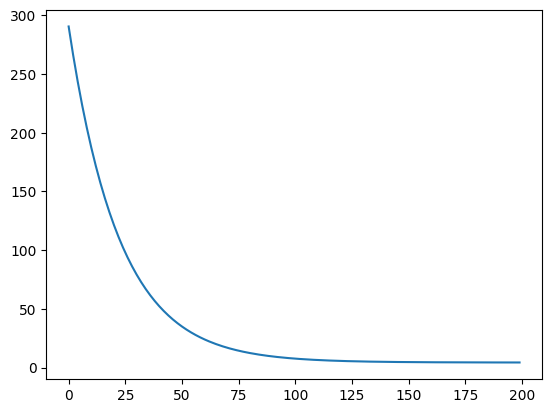

In [43]:
# matrix form
np.random.seed(17)
n = 100

X = np.random.randn(n,2).astype('float32')
y = X[:,0]*10 + X[:,1]*10 + 10
y = y + np.random.randn(n) * 2
y = y.reshape(-1,1)

W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))

print(X.shape, y.shape, W.shape, b.shape)

learning_rate = 0.01
lossHistory = []

for i in range(200):
    with tf.GradientTape() as tape:
        y_pred = tf.matmul(X, W) + b
        cost = tf.reduce_mean(tf.square(y_pred - y))

    grads = tape.gradient(cost, [W, b])

    optimizer = tf.optimizers.SGD( learning_rate )
    optimizer.apply_gradients(zip(grads, [W,b]))

    lossHistory.append(cost)
    if i % 50 == 0:
        print(i, W.numpy().T.round(2), b.numpy().round(2), cost.numpy())

plt.plot(lossHistory)

In [44]:
W, b

(<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
 array([[10.1526165],
        [ 9.731838 ]], dtype=float32)>,
 <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([9.606246], dtype=float32)>)

# Using Keras

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

[array([[10.196488]], dtype=float32), array([10.006516], dtype=float32)]


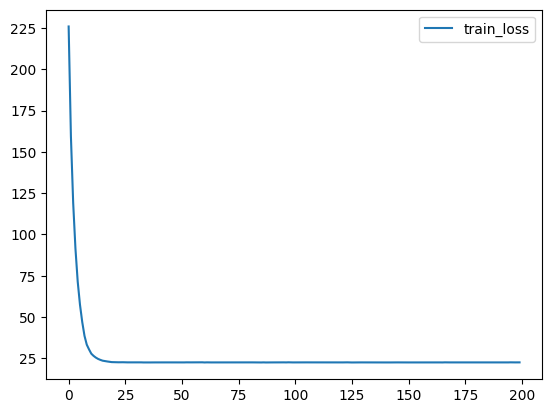

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import SGD

np.random.seed(17)
n = 100
x = np.random.randn(n)                # batch size
y = x*10 + 10                         # w=10, b=10 ???
y = y + np.random.randn(n) * 5        # add noise

#---------
model = Sequential()
model.add((Input(shape=(1,))))
model.add(Dense(1, activation='linear'))
model.summary()

model.compile(optimizer=SGD(learning_rate=1e-2), loss='mse')

history = model.fit(x, y, epochs=200, verbose=0, batch_size=16)

print([i.numpy() for i in model.weights])

# history.history.keys()
plt.plot(history.history['loss'], label='train_loss')
plt.legend(loc='best')

In [47]:
model.weights   # list of Variables  (read and write)

[<Variable path=sequential_1/dense_1/kernel, shape=(1, 1), dtype=float32, value=[[10.196488]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(1,), dtype=float32, value=[10.006516]>]

In [48]:
model.weights[0].numpy(), model.weights[1].numpy()

(array([[10.196488]], dtype=float32), array([10.006516], dtype=float32))

In [49]:
model.get_weights()   # list of numpy arrays (read-only access)

[array([[10.196488]], dtype=float32), array([10.006516], dtype=float32)]

In [50]:
model.evaluate(x,y)   # loss

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.4604  


22.4604434967041

# Logistic Regression Classifier

## using Tensorflow

(300, 2) (300, 1) (2, 1) (1,)
0 [[ 1.3380783 -0.554478 ]] [0.6429572] 0.37844023
20 [[ 1.2934527 -0.6450133]] [0.62954515] 0.27003697
40 [[ 1.2614664 -0.7050907]] [0.61990094] 0.22080824
60 [[ 1.2389814 -0.7456474]] [0.6127402] 0.19787136
80 [[ 1.2236408  -0.77298886]] [0.6072834] 0.18730675
100 [[ 1.2135121 -0.7913043]] [0.6029971] 0.18253861
120 [[ 1.2070546 -0.8035158]] [0.59950465] 0.18041627
140 [[ 1.2031114 -0.8116508]] [0.5965435] 0.17947066
160 [[ 1.2008549 -0.8170901]] [0.59393394] 0.17903817
180 [[ 1.1997142  -0.82075924]] [0.59155583] 0.1788264


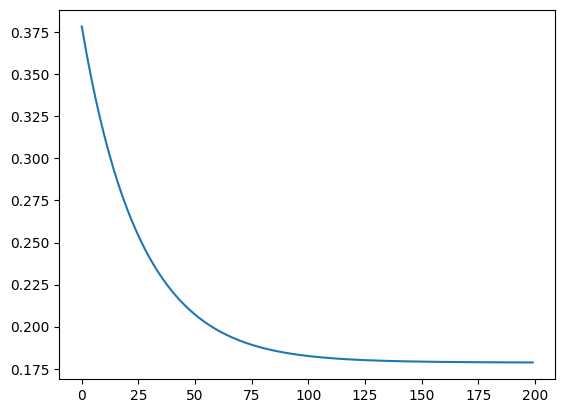

In [51]:
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(17)
(X, y) = make_blobs(n_samples=300, n_features=2, centers=2,
                    cluster_std=2.0, random_state=20)
X = X.astype('float32')
y = y.reshape(-1,1)

W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
print(X.shape, y.shape, W.shape, b.shape)

learning_rate = 0.005
lossHistory = []

for i in range(200):
    with tf.GradientTape() as tape:
        z = tf.matmul(X, W) + b
        y_pred = tf.math.divide(1., 1. + tf.exp(-z))  # sigmoid
        y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)
        loss = -tf.reduce_mean(y * tf.math.log(y_pred) + (1 - y) * tf.math.log(1 - y_pred))   # CE

    grads = tape.gradient(loss, [W, b])

    optimizer = tf.optimizers.SGD( learning_rate )
    optimizer.apply_gradients(zip(grads, [W, b]))

    lossHistory.append(loss)
    if i % 20 == 0:
        print(i, W.numpy().T, b.numpy(), loss.numpy())

plt.plot(lossHistory)

[]

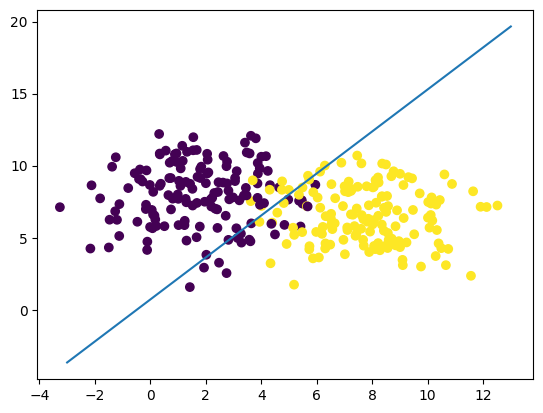

In [52]:
plt.scatter(X[:,0], X[:,1],c=y)
aa, bb, cc = W[0,0], W[1,0], b
xx = np.linspace(-3, 13, 100)
plt.plot (xx, -aa/bb * xx - cc/bb)
plt.plot()

## Version 2 (Tensorflow, by batches)

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[1.0132492 ],
       [0.54706764]], dtype=float32)> <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.3038286], dtype=float32)>
step:  0 [[0.96629316 0.35154703]] [-0.32797912] 2.797604
step:  5 [[ 0.7788703  -0.26605478]] [-0.40507454] 0.1994827
step:  10 [[ 0.7478495 -0.3860669]] [-0.42244673] 0.14509748
step:  15 [[ 0.7648785 -0.4156285]] [-0.42843443] 0.15663207
step:  20 [[ 0.7866328  -0.43285376]] [-0.432947] 0.11353444
step:  25 [[ 0.80801123 -0.44642526]] [-0.43708408] 0.1337657
step:  30 [[ 0.8274809  -0.45941845]] [-0.44122553] 0.17973387
step:  35 [[ 0.8451056 -0.472087 ]] [-0.44540158] 0.23694175
step:  40 [[ 0.8626952  -0.48207352]] [-0.4492879] 0.22563124
step:  45 [[ 0.8792496  -0.49124268]] [-0.4531278] 0.12126411


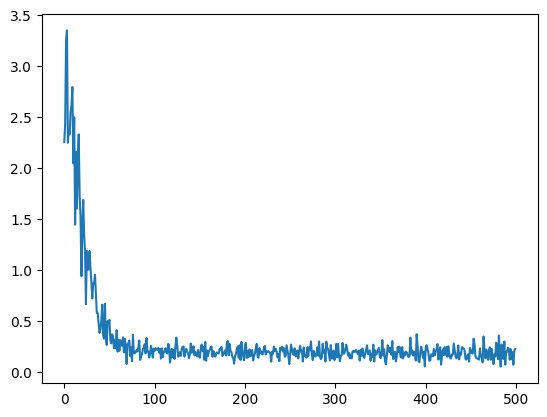

In [53]:
(X, y) = make_blobs(n_samples=320, n_features=2, centers=2,
                    cluster_std=2.0, random_state=20)
X, y = X.astype('float32'), y.reshape(-1,1).astype('float32')
dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(100).batch(32)

W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
print (W, b)

num_epochs = 50
learning_rate = 0.005

def logistic_regression(X):
    z = tf.matmul(X, W) + b
    return 1. / (1. + tf.exp(-z))

def loss_fn(y_pred, Y):
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)
    return -tf.reduce_mean(Y * tf.math.log(y_pred) + (1 - Y) * tf.math.log(1 - y_pred))

lossHistory = []
for step in range(num_epochs):
    for batch_x, batch_y in iter(dataset):
        with tf.GradientTape() as tape:
            y_pred = logistic_regression(batch_x)
            loss = loss_fn(y_pred, batch_y)

        grads = tape.gradient(loss, [W, b])
        optimizer = tf.optimizers.SGD( learning_rate )
        optimizer.apply_gradients(zip(grads, [W,b]))
        lossHistory.append(loss)
    if step%5 == 0:
        print("step: ", step, W.numpy().T, b.numpy(), loss.numpy())

plt.plot(lossHistory)

[]

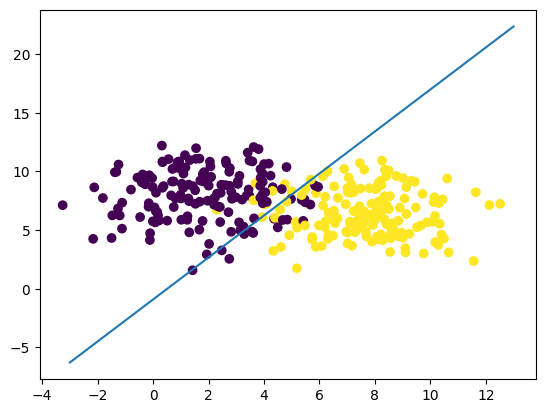

In [54]:
plt.scatter(X[:,0], X[:,1],c=y)
aa, bb, cc = W[0,0], W[1,0], b
xx = np.linspace(-3, 13, 100)
plt.plot (xx, -aa/bb * xx - cc/bb)
plt.plot()

## Logistic regression (with Keras)

In [56]:
from sklearn.datasets import make_blobs

np.random.seed(17)
N = 320
(X, y) = make_blobs(n_samples=N, n_features=2, centers=2,
                    cluster_std=2.0, random_state=20)

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer=SGD(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history = model.fit(X, y, epochs=50, batch_size=32, verbose=1)

print([i.numpy() for i in model.weights])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 5.2048  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5031 - loss: 3.4930 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5312 - loss: 1.8920 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6656 - loss: 0.7797 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8250 - loss: 0.3522 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8906 - loss: 0.2354 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.2048 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9094 - loss: 0.1960 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9156 - loss: 0.1934 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.1922 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9156 - loss: 0.1912 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [57]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

In [58]:
model.weights

[<Variable path=sequential_2/dense_2/kernel, shape=(2, 1), dtype=float32, value=[[ 1.0217404]
  [-0.6052698]]>,
 <Variable path=sequential_2/dense_2/bias, shape=(1,), dtype=float32, value=[-0.28106418]>]

In [59]:
model.weights[0].shape, model.weights[1].shape

(TensorShape([2, 1]), TensorShape([1]))

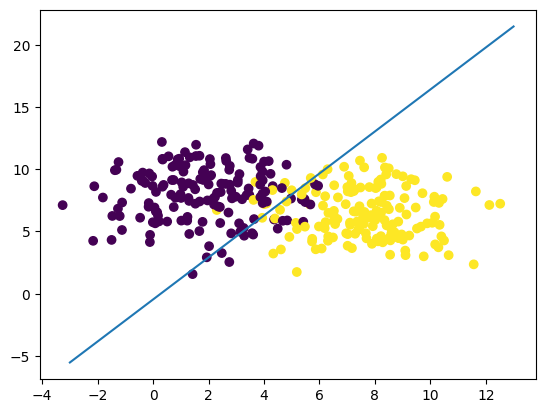

In [60]:
plt.scatter(X[:,0], X[:,1], c=y)
w1, w2 = model.weights[0][0,0], model.weights[0][1,0]
b = model.weights[1]
xx = np.linspace(-3, 13, 100)
yy = -w1/w2 * xx - b/w2
plt.plot(xx, yy)

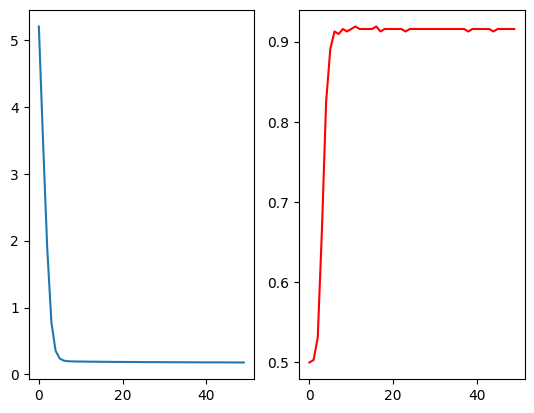

In [61]:
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy', c='r')
plt.show()

# Pytorch
- PyTorch에서는 Tensor가 곧 기본 데이터 구조이며, TensorFlow처럼 별도의 Variable 객체를 만들 필요가 없다.
- 예전에는 Variable이 있었지만 지금은 Tensor에 자동 미분 기능이 통합되어 있어서, 값 갱신과 연산 모두 Tensor로 처리한다.

- TensorFlow and Pytorch
  - TensorFlow:
    - tf.Tensor는 불변(immutable)
    - 학습 가능한 파라미터는 tf.Variable로 따로 생성해야 하며, assign()으로 값 갱신.
  - PyTorch:
    - 모든 것이 torch.Tensor로 표현됨.
    - requires_grad=True 옵션을 주면 자동 미분 추적이 활성화되어 학습 가능한 파라미터로 사용 가능.
    - 값 갱신은 in-place 연산(tensor.add_(), tensor.mul_())이나 optimizer가 직접 수행.

- torch.tensor() 의 속성
  - w.data: 텐서가 담고 있는 실제 데이터(값)를 가리킨다. 미분 추적(Autograd) 엔진이 감시하지 않는 순수 데이터 영역이다.
  - w.grad: 역전파(loss.backward())가 실행되었을 때 계산된 미분값(기울기)이 저장되는 곳이다. 초기 상태는 None이다.
  - w.requires_grad: 이 텐서의 미분을 계산할지 여부를 결정하는 불리언(True/False) 플래그다. 모델의 가중치로 쓰려면 True로 설정해야 한다.
- 값을 변경할 경우
  - 방법 1: w.copy_() 메서드 사용 (권장): 기존 텐서의 구조와 미분 추적 흐름을 깨지 않고 내부 값만 안전하게 덮어쓴다. (메서드 뒤에 언더바 _가 붙는 것은 제자리에서 값을 바꾼다는 In-place 연산을 의미한다.)
  - 방법 2: 미분 추적이 필요 없는 데이터 수정 (with torch.no_grad():) : 가중치를 직접 수정할 때는 주로 미분 계산을 일시적으로 끄는 torch.no_grad() 블록 안에서 연산하는 것이 PyTorch의 표준 방식이다.

In [104]:
# w.copy_() 매써드 사용

import torch

w = torch.tensor([5.0], requires_grad=True)

# 안전하게 값을 [1.0]으로 변경
w.data.copy_(torch.tensor([1.0]))

print(w)       # tensor([1.], requires_grad=True) -> 속성이 유지됨
print(w.data)  # tensor([1.])

tensor([1.], requires_grad=True)
tensor([1.])


In [105]:
# 미분 추적이 필요 없는 데이터 수정 (with torch.no_grad():

with torch.no_grad():
    w[0] = 7.0  # 안전하게 인덱싱으로 값 변경 가능

print(w)

tensor([7.], requires_grad=True)


## 1-Variable Linear Regression

--- Linear Regression 학습 시작 ---
Epoch    0/2000 | Loss: 303.4651
Epoch   20/2000 | Loss: 77.2384
Epoch   40/2000 | Loss: 48.5193
Epoch   60/2000 | Loss: 44.6774
Epoch   80/2000 | Loss: 44.1259
Epoch  100/2000 | Loss: 44.0399
Epoch  120/2000 | Loss: 44.0253
Epoch  140/2000 | Loss: 44.0227
Epoch  160/2000 | Loss: 44.0222
Epoch  180/2000 | Loss: 44.0221


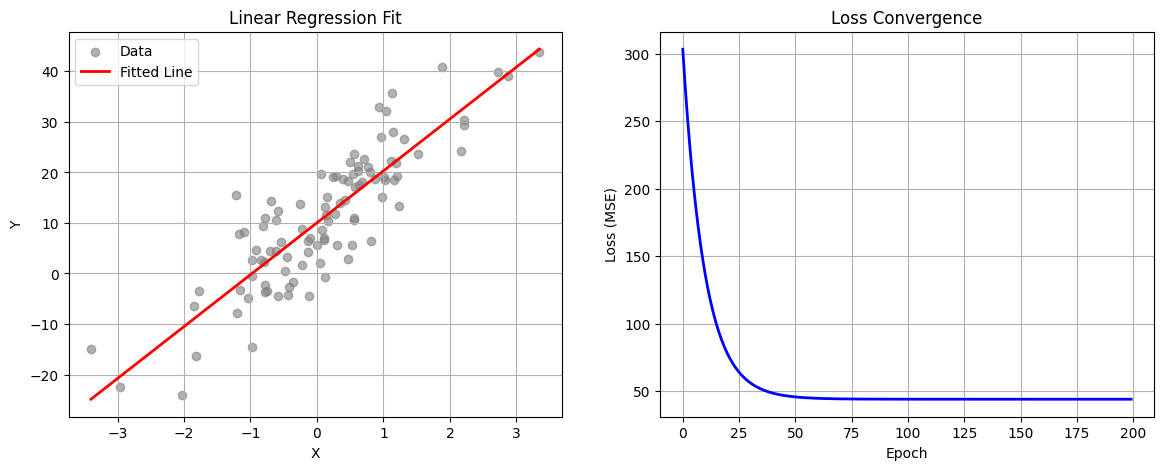

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. 시드 고정
np.random.seed(17)
torch.manual_seed(17)

# 2. 데이터 준비
n = 100
x_np = np.random.randn(n)
y_np = x_np * 10 + 10 + np.random.randn(n) * 7

# FloatTensor(): numpy 의 float64 데이터 -> PyTorch의 기본 연산 타입인 float32 텐서로 변환.
# unsqueeze(): 1차원 벡터를 2차원 행렬로 바꾸는 과정
x_train = torch.FloatTensor(x_np).unsqueeze(1)
y_train = torch.FloatTensor(y_np).unsqueeze(1)

# 3. 모델 정의
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.02)

# 손실 기록을 위한 리스트
loss_history = []

# 4. 모델 학습
print("--- Linear Regression 학습 시작 ---")
for epoch in range(200):
    prediction = model(x_train)
    loss = criterion(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 매 에포크마다 손실 기록
    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:4d}/2000 | Loss: {loss.item():.4f}")

final_w = model.linear.weight.item()
final_b = model.linear.bias.item()

# 5. 시각화 (데이터 피팅 + Loss 변화)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 데이터와 회귀선
ax1.scatter(x_np, y_np, color='gray', alpha=0.6, label='Data')
x_range = np.linspace(x_np.min(), x_np.max(), 100)
y_pred = final_w * x_range + final_b
ax1.plot(x_range, y_pred, color='red', linewidth=2, label='Fitted Line')
ax1.set_title('Linear Regression Fit')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()
ax1.grid(True)

# 오른쪽: Loss 변화 그래프
ax2.plot(loss_history, color='blue', linewidth=2)
ax2.set_title('Loss Convergence')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.grid(True)

plt.show()

## 2-Variable Logistic Regression

--- Logistic Regression 학습 시작 ---
Epoch    0/2000 | Loss: 0.6954
Epoch   20/2000 | Loss: 0.4880
Epoch   40/2000 | Loss: 0.3939
Epoch   60/2000 | Loss: 0.3393
Epoch   80/2000 | Loss: 0.3029
Epoch  100/2000 | Loss: 0.2766
Epoch  120/2000 | Loss: 0.2566
Epoch  140/2000 | Loss: 0.2406
Epoch  160/2000 | Loss: 0.2276
Epoch  180/2000 | Loss: 0.2167


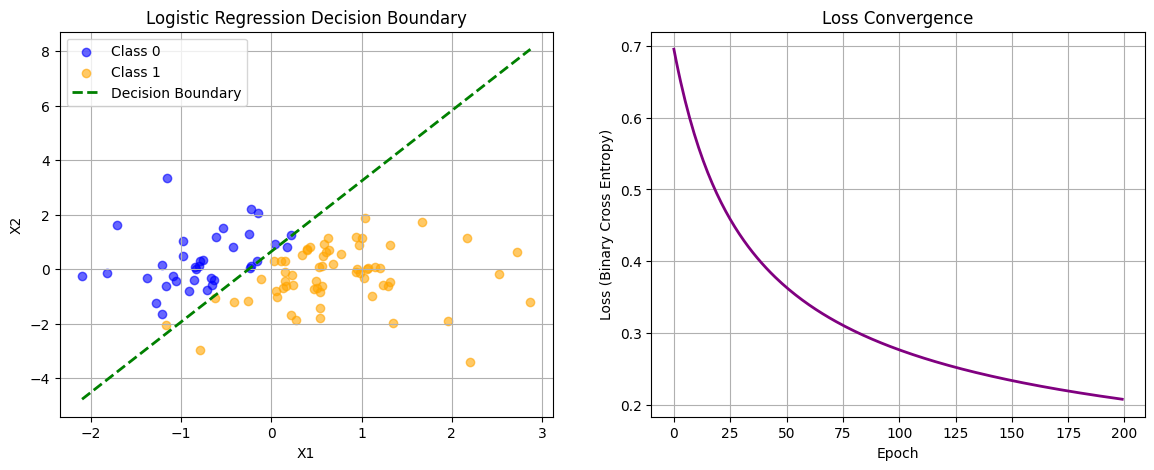

In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. 시드 고정
np.random.seed(17)
torch.manual_seed(17)

# 2. 데이터 준비
n = 100
x_np = np.random.randn(n, 2)
true_w = np.array([[2.5], [-1.5]])
true_b = 0.5
y_np = (1 / (1 + np.exp(-(np.dot(x_np, true_w) + true_b))) > 0.5).astype(np.float32)

x_train = torch.FloatTensor(x_np)
y_train = torch.FloatTensor(y_np)

# 3. 모델 정의
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.linear(x))

model = LogisticRegressionModel()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 손실 기록을 위한 리스트
loss_history = []

# 4. 모델 학습
print("--- Logistic Regression 학습 시작 ---")
for epoch in range(200):
    prediction = model(x_train)
    loss = criterion(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 매 에포크마다 손실 기록
    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:4d}/2000 | Loss: {loss.item():.4f}")

final_w = model.linear.weight.detach().numpy()
final_b = model.linear.bias.item()

# 5. 시각화 (결정 경계선 + Loss 변화)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 결정 경계선
ax1.scatter(x_np[y_np.flatten() == 0, 0], x_np[y_np.flatten() == 0, 1], color='blue', alpha=0.6, label='Class 0')
ax1.scatter(x_np[y_np.flatten() == 1, 0], x_np[y_np.flatten() == 1, 1], color='orange', alpha=0.6, label='Class 1')
x1_range = np.linspace(x_np[:, 0].min(), x_np[:, 0].max(), 100)
x2_boundary = -(final_w[0, 0] * x1_range + final_b) / final_w[0, 1]
ax1.plot(x1_range, x2_boundary, color='green', linewidth=2, linestyle='--', label='Decision Boundary')
ax1.set_title('Logistic Regression Decision Boundary')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.legend()
ax1.grid(True)

# 오른쪽: Loss 변화 그래프
ax2.plot(loss_history, color='purple', linewidth=2)
ax2.set_title('Loss Convergence')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Cross Entropy)')
ax2.grid(True)

plt.show()

- PyTorch: nn.Linear(1, 1) 구조를 사용하면 내부적으로 weight와 bias 텐서가 nn.Parameter라는 객체로 자동 생성된다. 이 객체는 requires_grad=True 속성을 기본적으로 내장하고 있어, 개발자가 직접 미분 대상임을 선언하지 않아도 알아서 추적된다.
- (미분 시에는) PyTorch는 별도의 테이프 구문이 없다. 순전파 연산(model(x))이 진행되는 한 줄 한 줄마다 동적 계산 그래프(Dynamic Computation Graph)가 실시간으로 빌드된다. 이후 최상단 결과물인 loss 객체에서 .backward()를 호출하면 그래프를 역방향으로 추적하며 각 가중치 텐서 내부의 .grad 속성에 미분값을 자동으로 채워 넣는다.

-------------------------------

# Exercise

## Tensorflow 2.0 and Tensorflow.Keras


### 1. Eager execution (no Graph, no Session)
 - direct execution
 - no placeholder(), no gloval_variables_initializer()

In [ ]:
a = tf.constant(10)
b = tf.constant(20)
c = a + b
print(c, c.numpy())

tf.Tensor(30, shape=(), dtype=int32) 30


In [ ]:
w = tf.Variable(tf.random.normal([1]))
print(w)

for step in range(3):
    w = w + 100.0    # variable -> Tensor 로 바뀜
    print(w)

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.44966933], dtype=float32)>
tf.Tensor([99.55033], shape=(1,), dtype=float32)
tf.Tensor([199.55032], shape=(1,), dtype=float32)
tf.Tensor([299.55032], shape=(1,), dtype=float32)


In [ ]:
w = tf.Variable(tf.random.normal([1]))
print(w)

for step in range(3):
    w = w.assign_add([100.0])    # Variable 유지 (scalar 가 아닌 동일한 형태의 텐서를 주어야 함)
    print(w)

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.3179147], dtype=float32)>
<tf.Variable 'UnreadVariable' shape=(1,) dtype=float32, numpy=array([99.68208], dtype=float32)>
<tf.Variable 'UnreadVariable' shape=(1,) dtype=float32, numpy=array([199.68208], dtype=float32)>
<tf.Variable 'UnreadVariable' shape=(1,) dtype=float32, numpy=array([299.68207], dtype=float32)>


In [ ]:
a = tf.constant(1.0)   # function 에 직접 값을 넘겨줄 수 있음.
b = tf.constant(3.0)

def tensor_sum(x, y):
    return x + y

result = tensor_sum(a, b)

print(type(result), result, result.numpy())

<class 'tensorflow.python.framework.ops.EagerTensor'> tf.Tensor(4.0, shape=(), dtype=float32) 4.0


### high level API (keras)
- model, layers
- data generation (train, test)
- CNN, RNN, LSTM, GRU, ...
- model generation -> compile -> fit -> evaluate/predict -> save (or reload)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(2, activation='sigmoid'))
model.add(Dense(1, activation='linear'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam
# regression
model.compile(optimizer=SGD(learning_rate=0.1),
              loss='mse',
              metrics=['accuracy'])    # loss 는 기본

# binary classification
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# multinomial classification
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
'''
model.fit(x_train, y_train, epochs=10,
          batch_size=100,
          verbose=0,
          validation_split=0.2)

model.evaluate(x_test, y_test, epochs=10, batch_size=10)
model.predict(x_input_data, batch_size=100)
'''

'\nmodel.fit(x_train, y_train, epochs=10,\n          batch_size=100,\n          verbose=0,\n          validation_split=0.2)\n\nmodel.evaluate(x_test, y_test, epochs=10, batch_size=10)\nmodel.predict(x_input_data, batch_size=100)\n'

In [ ]:
'''
model.save("model_name.h5")
# and later
model = load_model("model_name.h5")
'''

'\nmodel.save("model_name.h5")\n# and later\nmodel = load_model("model_name.h5")\n'

#### input_shape and input_dim
- Input shape: simply tells the input layer what the shape of one sample looks like. Adding it to your input layer, will ensure that a match is made.

- Input dim: sometimes, though, you just have one dimension – which is the case with one-dimensional / flattened arrays, for example. In this case, you can also simply use input_dim: specifying the number of elements within that first dimension only.

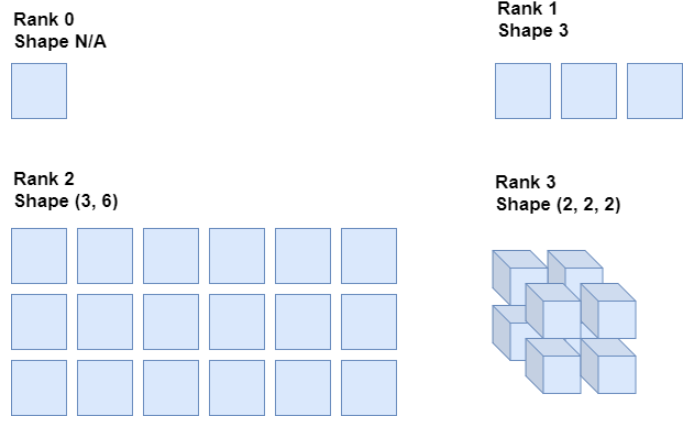

# Tensor manipulation

In [67]:
# Tensor basic variables
c0 = tf.constant(2.7)
c1 = tf.constant([1,2,3])
c0, type(c0), c1, type(c1)

(<tf.Tensor: shape=(), dtype=float32, numpy=2.700000047683716>,
 tensorflow.python.framework.ops.EagerTensor,
 <tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>,
 tensorflow.python.framework.ops.EagerTensor)

In [68]:
# all rank 0 (with initial values)
# 문자열은 문자 시퀀스가 아니고 단일 객체로 다루어짐.

hi = tf.Variable("Hello", tf.string)
ignition = tf.Variable(451, tf.int16)
floating = tf.Variable(3.14159265359, tf.float64)
its_complicated = tf.Variable(12.3 - 4.85j, tf.complex64)

In [69]:
hi, type(hi), tf.rank(hi)

(<tf.Variable 'Variable:0' shape=() dtype=string, numpy=b'Hello'>,
 tensorflow.python.ops.resource_variable_ops.ResourceVariable,
 <tf.Tensor: shape=(), dtype=int32, numpy=0>)

In [70]:
# rank 1
mystr = tf.Variable(["Hello"], tf.string)
f_numbers  = tf.Variable([3.14159, 2.71828], tf.float32)
primes = tf.Variable([2, 3, 5, 7, 11], tf.int32)
comp = tf.Variable([12.3 - 4.85j, 7.5 - 6.23j], tf.complex128)

In [71]:
comp.dtype, type(comp), mystr

(tf.complex128,
 tensorflow.python.ops.resource_variable_ops.ResourceVariable,
 <tf.Variable 'Variable:0' shape=(1,) dtype=string, numpy=array([b'Hello'], dtype=object)>)

In [72]:
# rank 2
data1 = tf.Variable([1, 2], tf.int32)
data2 = tf.Variable([[1., 2.]], tf.float32)
data3 = tf.Variable([[False, True],[True, False]], tf.bool)
data4 = tf.Variable([[4, 2], [9, 3], [16, 4], [25, 5]], tf.int32)

In [73]:
data1, data2, data3, data4, type(data4)

(<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([1, 2], dtype=int32)>,
 <tf.Variable 'Variable:0' shape=(1, 2) dtype=float32, numpy=array([[1., 2.]], dtype=float32)>,
 <tf.Variable 'Variable:0' shape=(2, 2) dtype=bool, numpy=
 array([[False,  True],
        [ True, False]])>,
 <tf.Variable 'Variable:0' shape=(4, 2) dtype=int32, numpy=
 array([[ 4,  2],
        [ 9,  3],
        [16,  4],
        [25,  5]], dtype=int32)>,
 tensorflow.python.ops.resource_variable_ops.ResourceVariable)

In [74]:
data1.shape, data2.shape, data3.shape, data4.shape, type(data4.shape)

(TensorShape([2]),
 TensorShape([1, 2]),
 TensorShape([2, 2]),
 TensorShape([4, 2]),
 tensorflow.python.framework.tensor_shape.TensorShape)

In [75]:
my_image = tf.zeros([10, 299, 299, 3])  # 4 차원 텐서: 배치 x 높이 x 너비 x 색상

In [76]:
# rank 3 and reshaping
rank_3_tensor = tf.ones([3, 4, 5])
matrix = tf.reshape(rank_3_tensor, [6, 10])
matrixB = tf.reshape(matrix, [3, -1])
matrixAlt = tf.reshape(matrixB, [4, 3, -1])  # -1은 자동 결정하라는 뜻
# yet_another = tf.reshape(matrixAlt, [13, 2, -1])  # 에러!

In [77]:
matrix, matrixB, matrixAlt

(<tf.Tensor: shape=(6, 10), dtype=float32, numpy=
 array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float32)>,
 <tf.Tensor: shape=(3, 20), dtype=float32, numpy=
 array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.]], dtype=float32)>,
 <tf.Tensor: shape=(4, 3, 5), dtype=float32, numpy=
 array([[[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]],
 
        [[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]],
 
        [[1., 1., 1., 1

In [78]:
f_tensor = tf.cast(tf.constant([1, 2, 3]), dtype=tf.float32)
f_tensor.dtype

tf.float32

# Exercise
- GradientTape():
  - trainable variables (created by tf.Variable or tf.compat.v1.get_variable, where trainable=True is default in both cases) are automatically watched. Tensors can be manually watched by invoking the watch method on this context manager.
  - By default GradientTape will automatically watch any trainable variables that are accessed inside the context
- 텐서플로는 자동 미분(주어진 입력 변수에 대한 연산의 그래디언트(gradient)를 계산하는 것)을 위한 tf.GradientTape API를 제공한다. tf.GradientTape는 컨텍스트(context) 안에서 실행된 모든 연산을 테이프(tape)에 "기록" 한다. 그 다음 텐서플로는 후진 방식 자동 미분(reverse mode differentiation)을 사용해 테이프에 "기록된" 연산의 그래디언트를 계산한다.

In [79]:
x = tf.constant(3.0)
with tf.GradientTape(persistent=True) as tape:
    tape.watch(x)
    y = x * x
    z = y * y

dz_dx = tape.gradient(z, x)  # 108.0 (4*x^3 at x = 3)
dy_dx = tape.gradient(y, x)  # 6.0
# del tape  # Drop the reference to the tape

dz_dx, dy_dx


(<tf.Tensor: shape=(), dtype=float32, numpy=108.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=6.0>)

In [80]:
# Be careful when you use tape.gradient()

W = tf.Variable(4.5)

for i in range(5):
    with tf.GradientTape() as tape:
       tape.watch(W)                   # watch W
       y = W * W
       W_grad = tape.gradient(y, W)
    W = W - learning_rate * W_grad     # W will be chaned from Variable to Tensor.
                                       # so, you need to tell to watch it.
                                       # if not, tape.gradient() will return None.
print (W)

tf.Tensor(4.279455, shape=(), dtype=float32)


In [81]:
# zip
numbers = [1,2,3,4]
names = ['hong','gil','dong','nim']
dic = {}

for number , name in zip(numbers, names):
    dic[number] = name
print(dic)

# or
list(zip(numbers, names))

{1: 'hong', 2: 'gil', 3: 'dong', 4: 'nim'}


[(1, 'hong'), (2, 'gil'), (3, 'dong'), (4, 'nim')]

In [82]:
z = zip(numbers, names)

In [83]:
z

In [84]:
next(z)   # try one at a time

(1, 'hong')

In [85]:
[(i,j) for i,j in zip(numbers, names)]

[(1, 'hong'), (2, 'gil'), (3, 'dong'), (4, 'nim')]

In [86]:
x = 21
y = 3
try:
    zip(x, y)
except:
    print("error: zip argument #1 must support iteration")

error: zip argument #1 must support iteration


In [87]:
x = [21]
y = [3]
zip(x, y)

In [88]:
t1 = tf.constant([77,88,99])
t2 = tf.Variable([77,88,99])
n1 = [1,2,3]
t1, t2

(<tf.Tensor: shape=(3,), dtype=int32, numpy=array([77, 88, 99], dtype=int32)>,
 <tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([77, 88, 99], dtype=int32)>)

In [89]:
[(i.numpy(),j) for i, j in zip(t1,n1)]

[(np.int32(77), 1), (np.int32(88), 2), (np.int32(99), 3)]

In [90]:
[(i.numpy(),j) for i, j in zip(t2,n1)]

[(np.int32(77), 1), (np.int32(88), 2), (np.int32(99), 3)]

- exercise

In [91]:
a, b = 3, 4
tf.add(a, b)

<tf.Tensor: shape=(), dtype=int32, numpy=7>

In [92]:
a, b = tf.constant(3), tf.constant(4)
a + b, tf.add(a, b)

(<tf.Tensor: shape=(), dtype=int32, numpy=7>,
 <tf.Tensor: shape=(), dtype=int32, numpy=7>)